# 🏅 Análise de Medalhas Olímpicas por País (1896-2024)

## 👥 Autores
Carlos Lavor Neto & Alexandro Pantoja - UEA

## 📋 Objetivos
- Consolidar medalhas por país (Verão, Inverno, Total)
- Gerar 3 tabelas ordenadas por total de medalhas
- Gerar 3 gráficos Top 50 países
- Integrar dados 1896-2022 + Paris 2024


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10

print("✅ Bibliotecas carregadas!")

✅ Bibliotecas carregadas!


In [2]:
BASE_PATH = Path('..')
RAW_PATH = BASE_PATH / 'raw'
BRONZE_PATH = BASE_PATH / 'bronze'
GOLD_PATH = BASE_PATH / 'gold'
OUTPUTS_PATH = BASE_PATH / 'outputs'

print(f"✅ Caminhos configurados")

✅ Caminhos configurados


---
## 1. Carregamento e Integração de Dados

In [3]:
# Carregar dados históricos 1896-2022
df_hist = pd.read_csv(RAW_PATH / 'Olympics_1896_2022' / 'world_olympedia_olympics_game_medal_tally.csv')
print(f"Dados históricos: {len(df_hist):,} registros")

# Carregar dados Paris 2024
df_paris = pd.read_csv(RAW_PATH / 'Olympics_Paris2024' / 'medals_total.csv')
print(f"Dados Paris 2024: {len(df_paris):,} registros")

# Preparar Paris 2024
df_paris['year'] = 2024
df_paris['edition'] = '2024 Summer Olympics'
if 'country_code' in df_paris.columns:
    df_paris = df_paris.rename(columns={'country_code': 'country_noc'})

# Adicionar coluna season
if 'season' not in df_hist.columns:
    df_hist['season'] = df_hist['edition'].apply(lambda x: 'Winter' if 'Winter' in str(x) else 'Summer')
df_paris['season'] = 'Summer'

# Integrar
df_integrated = pd.concat([df_hist, df_paris], ignore_index=True)

# Salvar integrado
df_integrated.to_parquet(BRONZE_PATH / 'medals_integrated.parquet', index=False)

print(f"\n✅ Dados integrados: {len(df_integrated):,} registros")
print(f"   Período: {df_integrated['year'].min()}-{df_integrated['year'].max()}")
print(f"   Países: {df_integrated['country_noc'].nunique()}")

Dados históricos: 1,807 registros
Dados Paris 2024: 92 registros

✅ Dados integrados: 1,899 registros
   Período: 1896-2024
   Países: 160


---
## 2. Análise 1.1 - Tabelas Consolidadas

In [4]:
# Função para criar tabela consolidada
def create_table(df, season_filter=None, name=''):
    if season_filter:
        df_filtered = df[df['season'] == season_filter]
    else:
        df_filtered = df
    
    # Agrupar por país
    result = df_filtered.groupby('country_noc').agg({
        'gold': 'sum',
        'silver': 'sum',
        'bronze': 'sum',
        'total': 'sum'
    }).reset_index()
    
    # Ordenar
    result = result.sort_values('total', ascending=False).reset_index(drop=True)
    result.insert(0, 'rank', range(1, len(result) + 1))
    
    return result

# 1. Jogos de Verão
df_summer = create_table(df_integrated, 'Summer', 'Verão')
print("\n" + "="*80)
print("MEDALHAS - JOGOS DE VERÃO (1896-2024)")
print("="*80)
print(df_summer.head(20).to_string(index=False))
print(f"\n... Total de {len(df_summer)} países com medalhas")

df_summer.to_csv(OUTPUTS_PATH / 'tables' / 'medals_summer.csv', index=False)
df_summer.to_parquet(GOLD_PATH / 'medals_summer.parquet', index=False)

# 2. Jogos de Inverno
df_winter = create_table(df_integrated, 'Winter', 'Inverno')
print("\n" + "="*80)
print("MEDALHAS - JOGOS DE INVERNO (1896-2024)")
print("="*80)
print(df_winter.head(20).to_string(index=False))
print(f"\n... Total de {len(df_winter)} países com medalhas")

df_winter.to_csv(OUTPUTS_PATH / 'tables' / 'medals_winter.csv', index=False)
df_winter.to_parquet(GOLD_PATH / 'medals_winter.parquet', index=False)

# 3. Total Geral
df_total = create_table(df_integrated, None, 'Total')
print("\n" + "="*80)
print("MEDALHAS - TOTAL GERAL (1896-2024)")
print("="*80)
print(df_total.head(20).to_string(index=False))
print(f"\n... Total de {len(df_total)} países com medalhas")

df_total.to_csv(OUTPUTS_PATH / 'tables' / 'medals_total.csv', index=False)
df_total.to_parquet(GOLD_PATH / 'medals_total.parquet', index=False)

print("\n✅ 3 tabelas geradas e salvas!")


MEDALHAS - JOGOS DE VERÃO (1896-2024)
 rank country_noc   gold  silver  bronze  total
    1         USA 1082.0   847.0   750.0 2679.0
    2         URS  395.0   319.0   296.0 1010.0
    3         GBR  300.0   334.0   320.0  954.0
    4         FRA  246.0   266.0   301.0  813.0
    5         GER  243.0   273.0   296.0  812.0
    6         ITA  229.0   201.0   218.0  648.0
    7         CHN  263.0   199.0   174.0  636.0
    8         AUS  162.0   170.0   212.0  544.0
    9         HUN  184.0   161.0   180.0  525.0
   10         SWE  151.0   182.0   188.0  521.0
   11         JPN  169.0   150.0   180.0  499.0
   12         RUS  148.0   130.0   153.0  431.0
   13         GDR  153.0   129.0   127.0  409.0
   14         NED   98.0   107.0   127.0  332.0
   15         CAN   71.0   112.0   145.0  328.0
   16         FIN  106.0    87.0   121.0  314.0
   17         ROU   90.0    97.0   121.0  308.0
   18         POL   75.0    91.0   140.0  306.0
   19         KOR   96.0    91.0   100.0  287.0
 

---
## 3. Análise 1.2 - Gráficos Top 50


📊 Gerando gráficos...


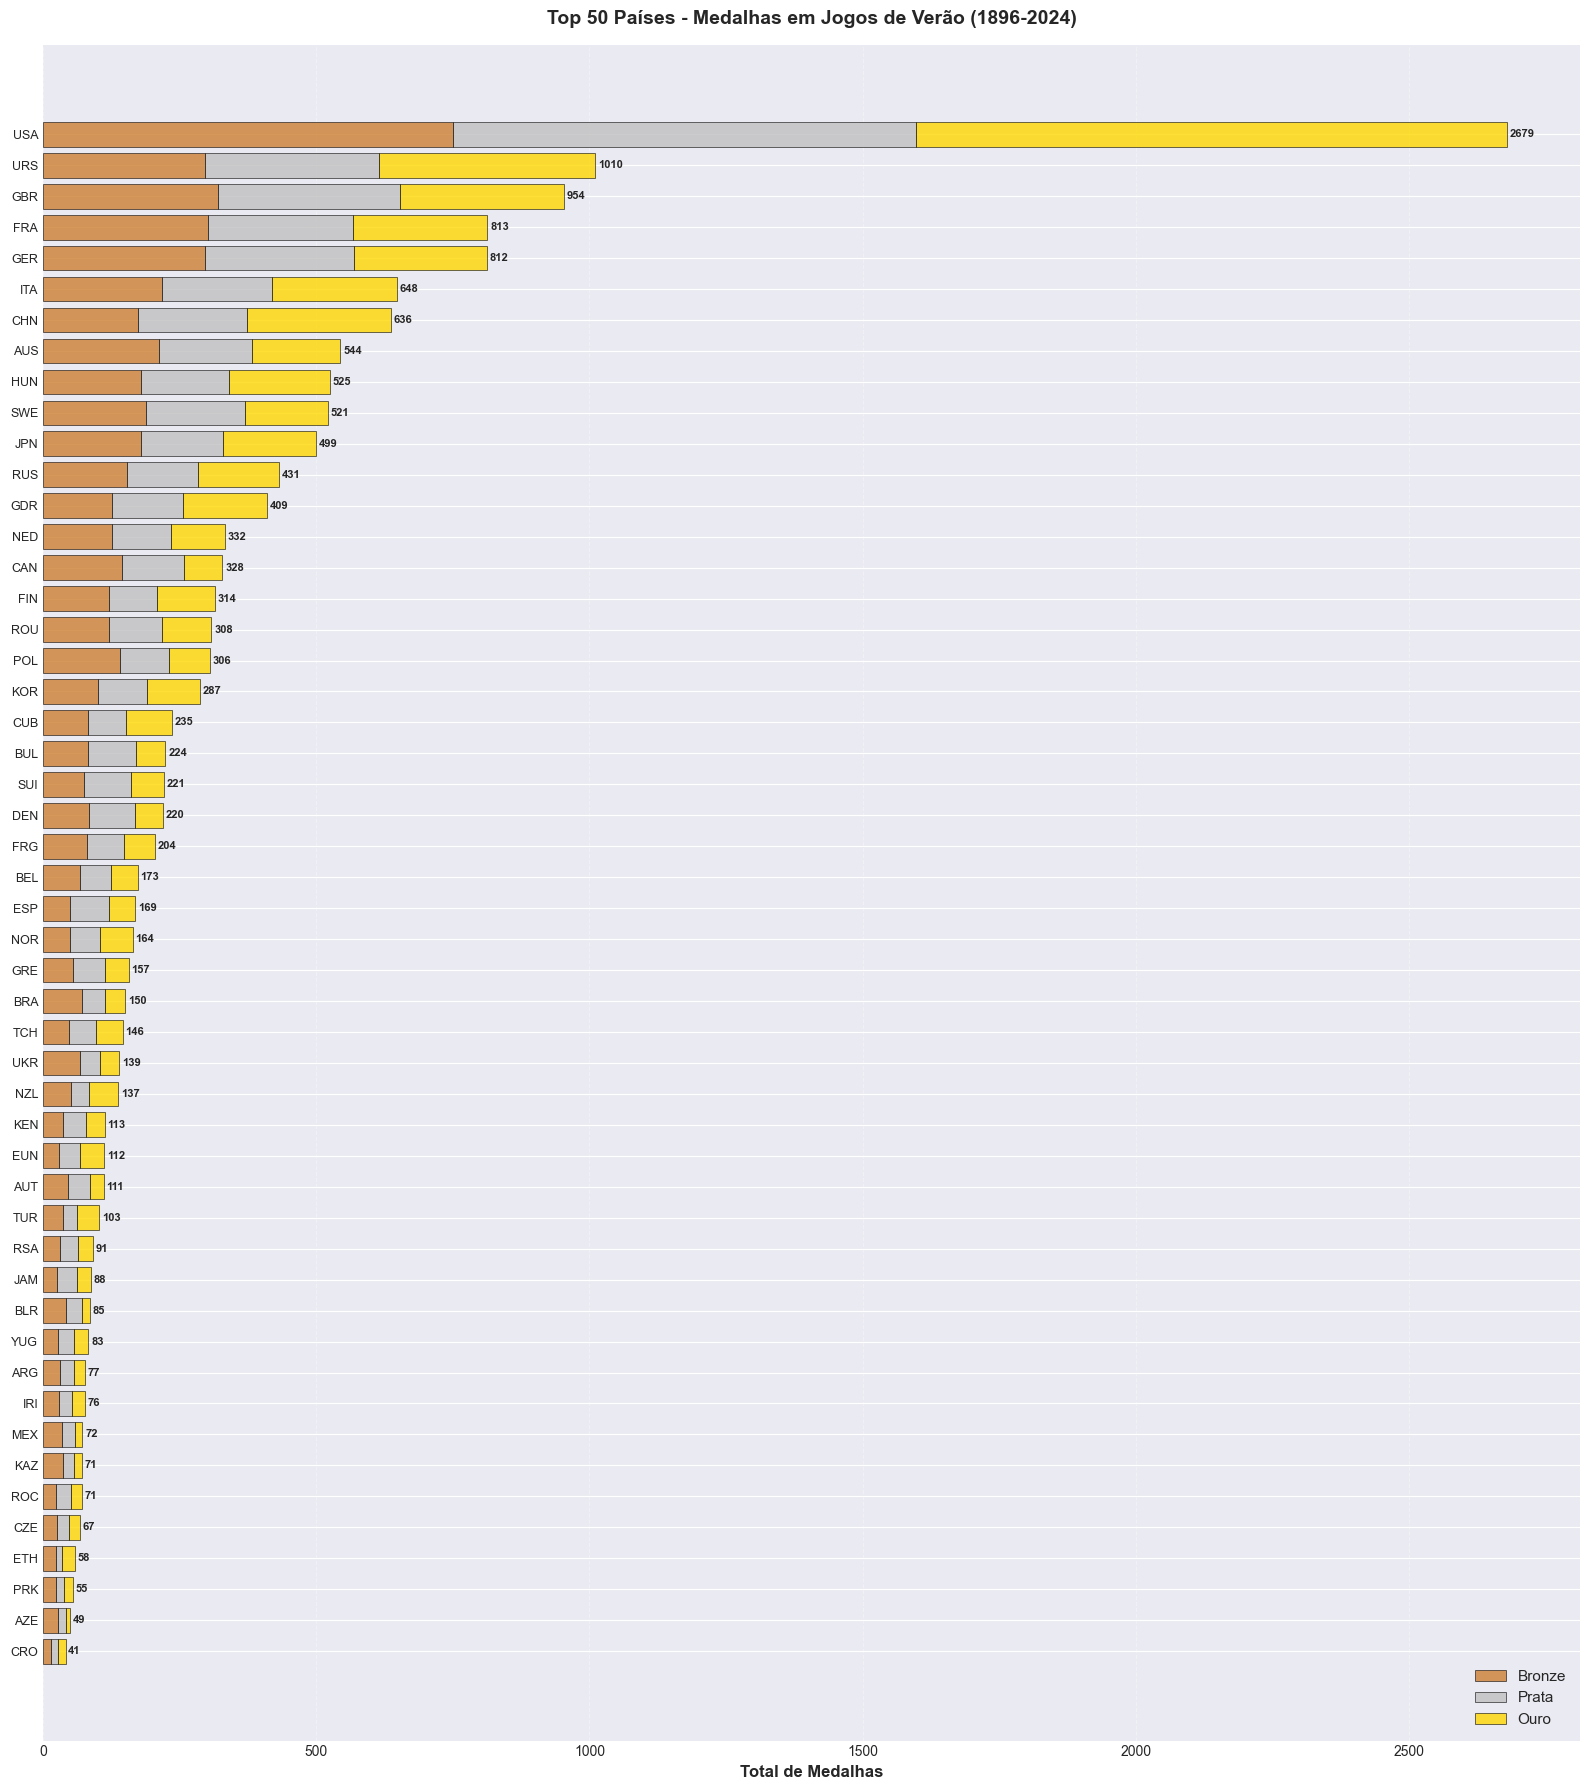

✅ Salvo: top50_summer.png


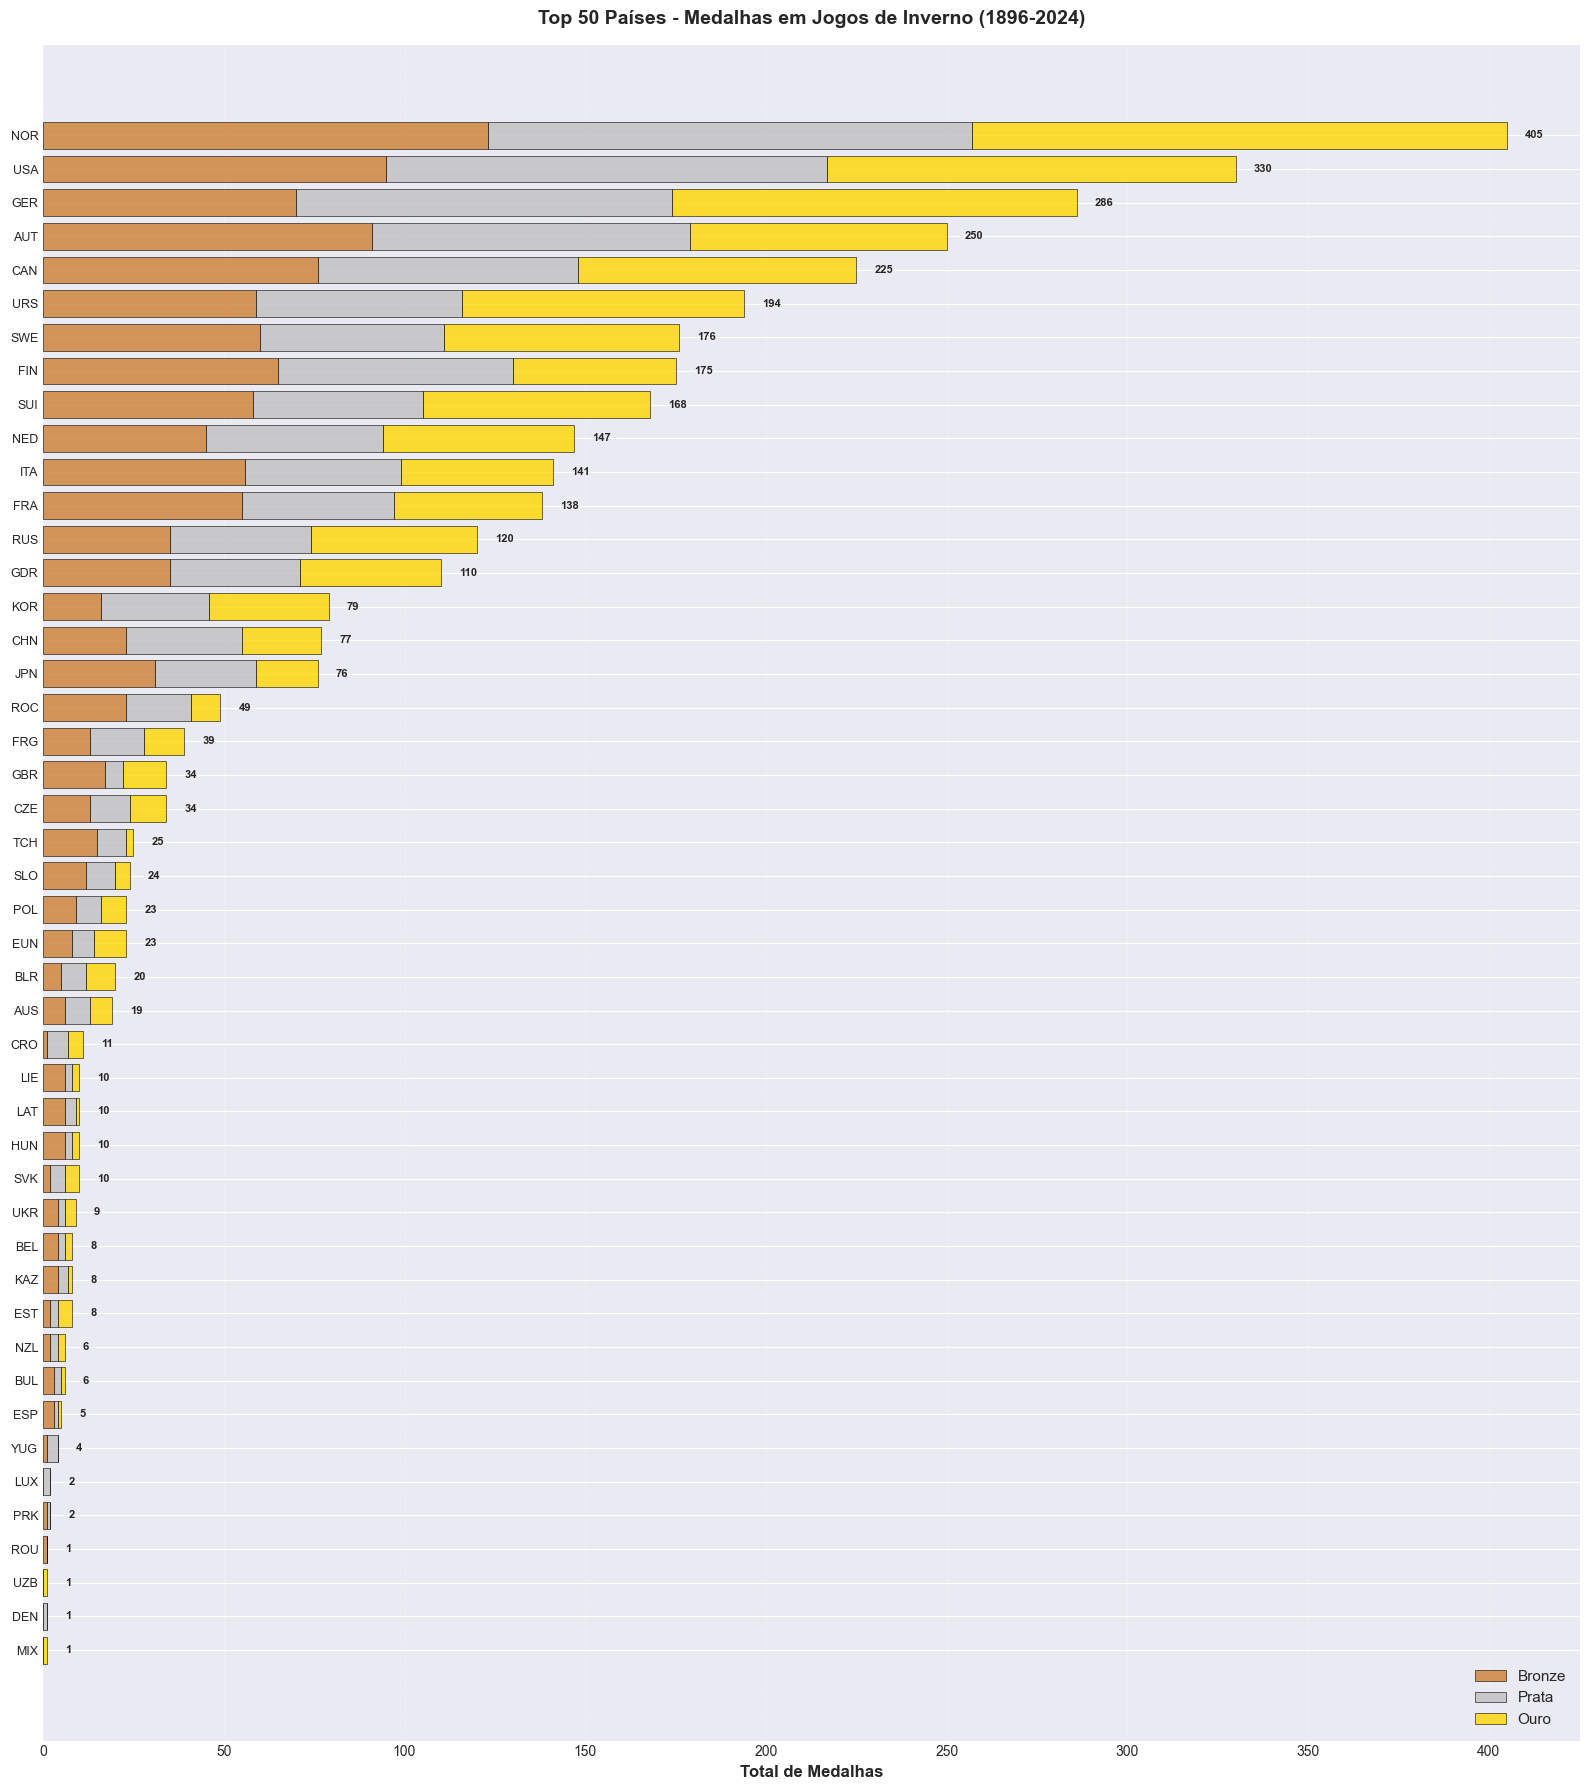

✅ Salvo: top50_winter.png


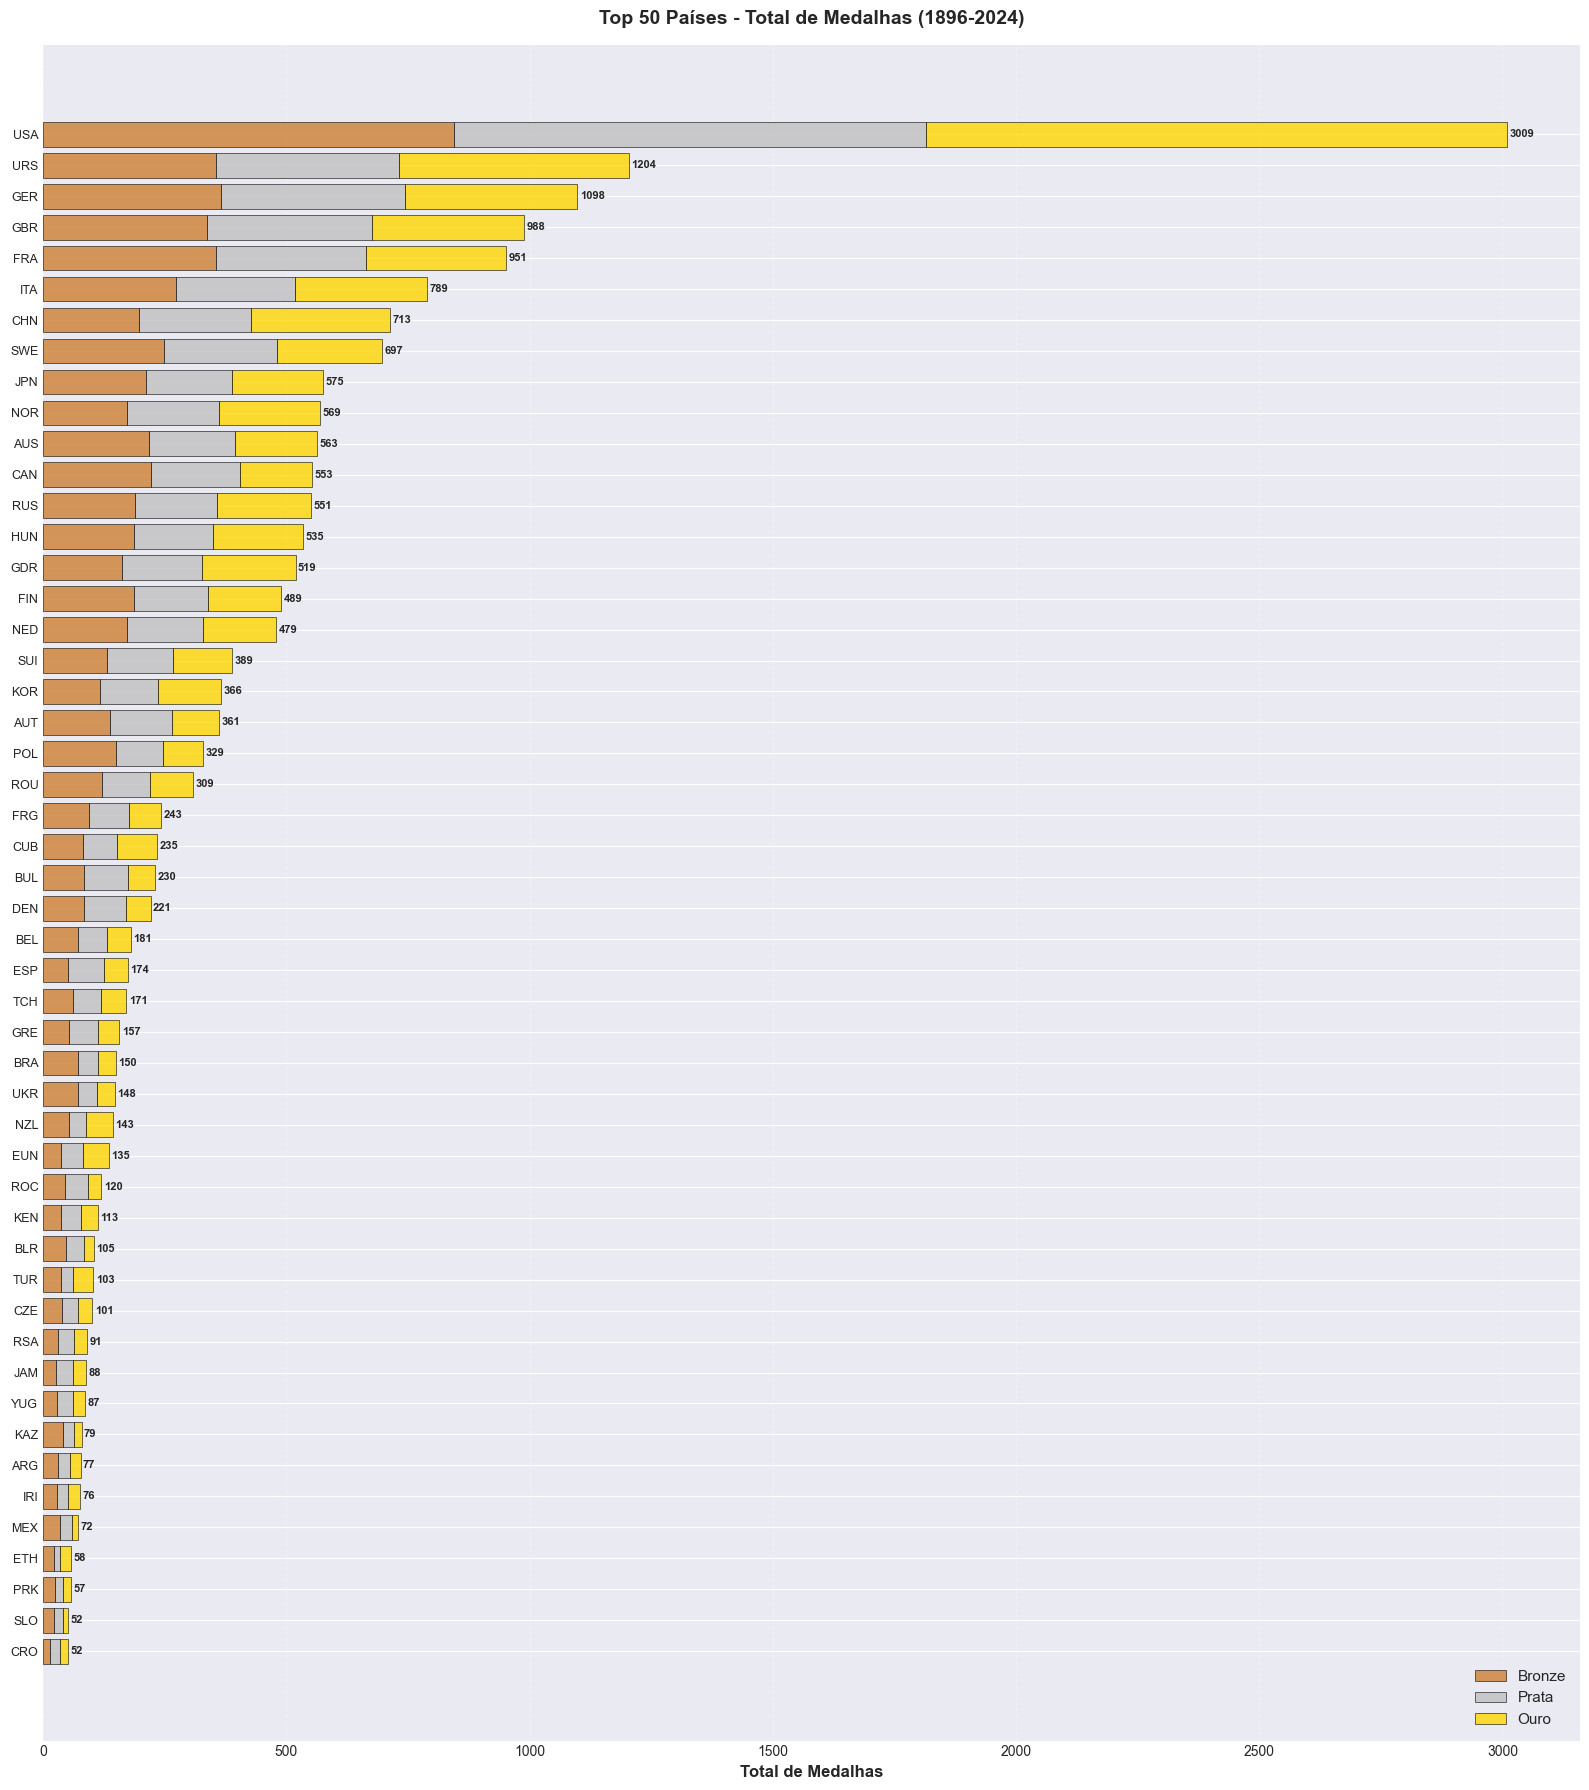

✅ Salvo: top50_total.png

✅ 3 gráficos gerados!


In [5]:
def plot_medals(df, title, filename):
    # Top 50
    df_plot = df.head(50).sort_values('total', ascending=True)
    
    fig, ax = plt.subplots(figsize=(16, 18))
    
    y_pos = np.arange(len(df_plot))
    
    # Barras empilhadas
    ax.barh(y_pos, df_plot['bronze'], color='#CD7F32', alpha=0.8, label='Bronze', edgecolor='black', linewidth=0.5)
    ax.barh(y_pos, df_plot['silver'], left=df_plot['bronze'], color='#C0C0C0', alpha=0.8, label='Prata', edgecolor='black', linewidth=0.5)
    ax.barh(y_pos, df_plot['gold'], left=df_plot['bronze']+df_plot['silver'], color='#FFD700', alpha=0.8, label='Ouro', edgecolor='black', linewidth=0.5)
    
    # Configurações
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_plot['country_noc'], fontsize=9)
    ax.set_xlabel('Total de Medalhas', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Adicionar valores totais
    for i, (idx, row) in enumerate(df_plot.iterrows()):
        ax.text(row['total'] + 5, i, str(int(row['total'])), 
               va='center', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_PATH / 'figures' / filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Salvo: {filename}")

# Gerar gráficos
print("\n📊 Gerando gráficos...")

plot_medals(df_summer, 'Top 50 Países - Medalhas em Jogos de Verão (1896-2024)', 'top50_summer.png')
plot_medals(df_winter, 'Top 50 Países - Medalhas em Jogos de Inverno (1896-2024)', 'top50_winter.png')
plot_medals(df_total, 'Top 50 Países - Total de Medalhas (1896-2024)', 'top50_total.png')

print("\n✅ 3 gráficos gerados!")

---
## 4. Criação de Metadados

In [6]:
# Criar metadados para cada resultado
metadata_sets = [
    ('medals_summer', 'Medalhas Jogos de Verão', len(df_summer)),
    ('medals_winter', 'Medalhas Jogos de Inverno', len(df_winter)),
    ('medals_total', 'Medalhas Total Geral', len(df_total))
]

for name, desc, count in metadata_sets:
    meta = {
        'nome': desc,
        'periodo': '1896-2024',
        'total_paises': count,
        'colunas': ['rank', 'country_noc', 'gold', 'silver', 'bronze', 'total'],
        'fonte': 'Olympedia (1896-2022) + Olympics.com (Paris 2024)',
        'criado_em': datetime.now().isoformat()
    }
    
    with open(GOLD_PATH / f'{name}_metadata.json', 'w') as f:
        json.dump(meta, f, indent=2)
    
    print(f"✅ Metadados: {name}_metadata.json")

print("\n✅ Metadados criados!")

✅ Metadados: medals_summer_metadata.json
✅ Metadados: medals_winter_metadata.json
✅ Metadados: medals_total_metadata.json

✅ Metadados criados!


---
## ✅ Resumo Final

In [7]:
print("="*80)
print("🎯 ANÁLISE COMPLETA EXECUTADA COM SUCESSO!")
print("="*80)
print(f"\n📊 Resultados:")
print(f"   - {len(df_summer)} países com medalhas em Jogos de Verão")
print(f"   - {len(df_winter)} países com medalhas em Jogos de Inverno")
print(f"   - {len(df_total)} países com medalhas no Total Geral")
print(f"\n📁 Arquivos gerados:")
print(f"   - 3 tabelas CSV em outputs/tables/")
print(f"   - 3 gráficos PNG em outputs/figures/")
print(f"   - 3 arquivos Parquet em gold/")
print(f"   - 3 metadados JSON em gold/")
print(f"\n🏆 Top 3 países (Total Geral):")
for i, row in df_total.head(3).iterrows():
    print(f"   {row['rank']}. {row['country_noc']}: {int(row['total'])} medalhas")
print("\n" + "="*80)

🎯 ANÁLISE COMPLETA EXECUTADA COM SUCESSO!

📊 Resultados:
   - 159 países com medalhas em Jogos de Verão
   - 46 países com medalhas em Jogos de Inverno
   - 160 países com medalhas no Total Geral

📁 Arquivos gerados:
   - 3 tabelas CSV em outputs/tables/
   - 3 gráficos PNG em outputs/figures/
   - 3 arquivos Parquet em gold/
   - 3 metadados JSON em gold/

🏆 Top 3 países (Total Geral):
   1. USA: 3009 medalhas
   2. URS: 1204 medalhas
   3. GER: 1098 medalhas

